In [1]:
import pandas as pd
from pathlib import Path
import spacy
import unicodedata
import numpy as np
from lexicalrichness import LexicalRichness
import textstat

In [2]:
nlp = spacy.load("en_core_web_md")

In [3]:
# ==========================================
# CONFIGURACIÓN
# ==========================================

carpeta_raiz = Path("0_CSV")

# ==========================================
# LEER TODOS LOS CSV
# ==========================================

lista_df = []

for archivo in carpeta_raiz.rglob("*.csv"):

    print(f"Leyendo: {archivo}")

    try:
        df = pd.read_csv(archivo)

        # Extraer entidad desde la carpeta contenedora
        entidad = archivo.relative_to(carpeta_raiz).parts[0]

        # Añadir columna Entidad
        df["Entidad"] = entidad

        # Guardar información de procedencia (opcional)
        df["archivo_origen"] = archivo.name

        lista_df.append(df)

    except Exception as e:
        print(f"Error en {archivo}: {e}")

# ==========================================
# UNIR TODOS LOS DATAFRAMES
# ==========================================

corpus = pd.concat(lista_df, ignore_index=True)

print(f"\nFilas totales: {len(corpus):,}")

# ==========================================
# CREAR TABLA DE DOCUMENTOS ÚNICOS
# ==========================================

docs = (
    corpus[["Entidad", "doc_name"]]
    .drop_duplicates()
    .sort_values(["Entidad", "doc_name"])
    .reset_index(drop=True)
)

# ==========================================
# NUMERAR DOCUMENTOS DENTRO DE CADA ENTIDAD
# ==========================================

docs["num_doc"] = docs.groupby("Entidad").cumcount() + 1

# ==========================================
# CREAR NUEVO IDENTIFICADOR
# ==========================================

docs["Documento"] = (
    docs["Entidad"]
    + "_doc_"
    + docs["num_doc"].astype(str)
)

# ==========================================
# UNIR AL CORPUS ORIGINAL
# ==========================================

corpus = corpus.merge(
    docs[["Entidad", "doc_name", "Documento"]],
    on=["Entidad", "doc_name"],
    how="left"
)

# ==========================================
# GUARDAR RESULTADO
# ==========================================

salida = "corpus_inmersia_raw.csv"

corpus.to_csv(
    salida,
    index=False,
    encoding="utf-8-sig"
)

print("\nProceso completado.")
print(f"Archivo generado: {salida}")
print(f"Documentos únicos: {len(docs):,}")

ValueError: No objects to concatenate

In [5]:
corpus = pd.read_csv("corpus_inmersia_raw.csv")
corpus.head()

,doc_name,original_path,token_index,token,lemma,pos,tag,dep,head,is_alpha,is_stop,sent_index,sent_text,text_full,Entidad,archivo_origen,Documento
0,07280560_data,C:/Users/X043585/Downloads/2024 Septiembre Ok/...,0,A,a,ADP,ADP,case,WONDERFUL,True,True,0,A WONDERFUL PLACE\n\nLast year.,A WONDERFUL PLACE\n\nLast year. I went to Piry...,GN,corpus_estudiantes1.csv,GN_doc_95
1,07280560_data,C:/Users/X043585/Downloads/2024 Septiembre Ok/...,1,WONDERFUL,WONDERFUL,PROPN,PROPN,ROOT,WONDERFUL,True,False,0,A WONDERFUL PLACE\n\nLast year.,A WONDERFUL PLACE\n\nLast year. I went to Piry...,GN,corpus_estudiantes1.csv,GN_doc_95
2,07280560_data,C:/Users/X043585/Downloads/2024 Septiembre Ok/...,2,PLACE,PLACE,PROPN,PROPN,flat,WONDERFUL,True,False,0,A WONDERFUL PLACE\n\nLast year.,A WONDERFUL PLACE\n\nLast year. I went to Piry...,GN,corpus_estudiantes1.csv,GN_doc_95
3,07280560_data,C:/Users/X043585/Downloads/2024 Septiembre Ok/...,3,\n\n,\n\n,SPACE,SPACE,dep,PLACE,False,False,0,A WONDERFUL PLACE\n\nLast year.,A WONDERFUL PLACE\n\nLast year. I went to Piry...,GN,corpus_estudiantes1.csv,GN_doc_95
4,07280560_data,C:/Users/X043585/Downloads/2024 Septiembre Ok/...,4,Last,Last,PROPN,PROPN,flat,PLACE,True,False,0,A WONDERFUL PLACE\n\nLast year.,A WONDERFUL PLACE\n\nLast year. I went to Piry...,GN,corpus_estudiantes1.csv,GN_doc_95


In [6]:
corpus.groupby("Entidad")["Documento"].nunique()

Entidad
CMA     1051
CNAI     498
GN      1321
Name: Documento, dtype: int64

In [7]:
corpus_sin_lematizar = corpus.drop_duplicates(subset="Documento")

In [8]:
corpus_sin_lematizar.shape

(2870, 17)

In [9]:
corpus.head()

,doc_name,original_path,token_index,token,lemma,pos,tag,dep,head,is_alpha,is_stop,sent_index,sent_text,text_full,Entidad,archivo_origen,Documento
0,07280560_data,C:/Users/X043585/Downloads/2024 Septiembre Ok/...,0,A,a,ADP,ADP,case,WONDERFUL,True,True,0,A WONDERFUL PLACE\n\nLast year.,A WONDERFUL PLACE\n\nLast year. I went to Piry...,GN,corpus_estudiantes1.csv,GN_doc_95
1,07280560_data,C:/Users/X043585/Downloads/2024 Septiembre Ok/...,1,WONDERFUL,WONDERFUL,PROPN,PROPN,ROOT,WONDERFUL,True,False,0,A WONDERFUL PLACE\n\nLast year.,A WONDERFUL PLACE\n\nLast year. I went to Piry...,GN,corpus_estudiantes1.csv,GN_doc_95
2,07280560_data,C:/Users/X043585/Downloads/2024 Septiembre Ok/...,2,PLACE,PLACE,PROPN,PROPN,flat,WONDERFUL,True,False,0,A WONDERFUL PLACE\n\nLast year.,A WONDERFUL PLACE\n\nLast year. I went to Piry...,GN,corpus_estudiantes1.csv,GN_doc_95
3,07280560_data,C:/Users/X043585/Downloads/2024 Septiembre Ok/...,3,\n\n,\n\n,SPACE,SPACE,dep,PLACE,False,False,0,A WONDERFUL PLACE\n\nLast year.,A WONDERFUL PLACE\n\nLast year. I went to Piry...,GN,corpus_estudiantes1.csv,GN_doc_95
4,07280560_data,C:/Users/X043585/Downloads/2024 Septiembre Ok/...,4,Last,Last,PROPN,PROPN,flat,PLACE,True,False,0,A WONDERFUL PLACE\n\nLast year.,A WONDERFUL PLACE\n\nLast year. I went to Piry...,GN,corpus_estudiantes1.csv,GN_doc_95


In [10]:
corpus_redux = corpus[["doc_name", "Entidad", "text_full"]]

In [11]:
corpus_sin_lematizar_redux = corpus_sin_lematizar[["doc_name", "Entidad", "text_full", "Documento"]]

In [12]:
# Crear un contador por entidad (empieza en 1)
corpus_sin_lematizar_redux["doc_num"] = corpus_sin_lematizar_redux.groupby("Entidad").cumcount() + 1

# Crear el nuevo nombre del documento
corpus_sin_lematizar_redux["doc_trans"] = (
    corpus_sin_lematizar_redux["Entidad"].astype(str)
    + "_doc_"
    + corpus_sin_lematizar_redux["doc_num"].astype(str)
)

# Eliminar la columna auxiliar
corpus_sin_lematizar_redux = corpus_sin_lematizar_redux.drop(columns="doc_num")

In [13]:
corpus_sin_lematizar_redux.drop("Documento", axis=1, inplace=True)
corpus_sin_lematizar_redux.drop("Entidad", axis=1, inplace=True)

In [14]:
corpus_sin_lematizar_redux

,doc_name,text_full,doc_trans
0,07280560_data,A WONDERFUL PLACE\n\nLast year. I went to Piry...,GN_doc_1
198,07281208_data,"Hi friends,\nI recently travelled to Valencia ...",GN_doc_2
393,07285712_data,"Hello Hi,\nthis Summer y when in Italy and I g...",GN_doc_3
607,09511640_data,"Hello friends,\nHere we gou again of this tour...",GN_doc_4
804,20921273_data,Hi guys!\nSorry for being desconected a lot of...,GN_doc_5
...,...,...,...
1214416,79417082_data,From: pturner@gmail.com\nTo: cinema club@gmail...,CNAI_doc_494
1214600,79417445_data,From: pturner@gmail.com\nTo: cinemaclub@gmail....,CNAI_doc_495
1214741,79417460_data,From: Pturner@gmail.com\nTO: cinemaclub@gmail....,CNAI_doc_496
1214873,79417528_data,From: pturna@gmail.com\nTo: cinemaclub@gmail.c...,CNAI_doc_497


In [15]:
# 1. Renombramos las columnas
corpus_sin_lematizar_redux = corpus_sin_lematizar_redux.rename(columns={'doc_name': 'archivo_origen', 'doc_trans': 'doc_name'})

# 2. Intercambiamos las posiciones (0 y 2) en la lista de columnas
cols = list(corpus_sin_lematizar_redux.columns)
cols[0], cols[2] = cols[2], cols[0]

# 3. Aplicamos el nuevo orden al DataFrame
corpus_sin_lematizar_redux = corpus_sin_lematizar_redux[cols]

In [16]:
corpus_sin_lematizar_redux.to_csv(
    "corpus_inmersia_0.csv",
    index=False
)

In [17]:
corpus_sin_lematizar_redux

,doc_name,text_full,archivo_origen
0,GN_doc_1,A WONDERFUL PLACE\n\nLast year. I went to Piry...,07280560_data
198,GN_doc_2,"Hi friends,\nI recently travelled to Valencia ...",07281208_data
393,GN_doc_3,"Hello Hi,\nthis Summer y when in Italy and I g...",07285712_data
607,GN_doc_4,"Hello friends,\nHere we gou again of this tour...",09511640_data
804,GN_doc_5,Hi guys!\nSorry for being desconected a lot of...,20921273_data
...,...,...,...
1214416,CNAI_doc_494,From: pturner@gmail.com\nTo: cinema club@gmail...,79417082_data
1214600,CNAI_doc_495,From: pturner@gmail.com\nTo: cinemaclub@gmail....,79417445_data
1214741,CNAI_doc_496,From: Pturner@gmail.com\nTO: cinemaclub@gmail....,79417460_data
1214873,CNAI_doc_497,From: pturna@gmail.com\nTo: cinemaclub@gmail.c...,79417528_data


In [18]:
def normalizar_texto(texto):
    if pd.isna(texto):
        return ""

    texto = str(texto)
    texto = unicodedata.normalize("NFC", texto)

    texto = texto.replace("\ufeff", "")
    texto = texto.replace("\u200b", "")
    texto = texto.replace("\xa0", " ")

    texto = " ".join(texto.split())

    return texto.strip()

In [19]:
corpus = corpus_sin_lematizar_redux.copy()

corpus["text_norm"] = corpus["text_full"].apply(normalizar_texto)

In [20]:
docs = list(
    nlp.pipe(
        corpus["text_norm"],
        batch_size=50
    )
)

In [21]:
def extraer_rasgos(doc):
    tokens = [t for t in doc if not t.is_space]
    words = [t for t in doc if t.is_alpha]
    sentences = list(doc.sents)

    n_tokens = len(tokens)
    n_words = len(words)
    n_sentences = len(sentences)

    lemmas = [t.lemma_.lower() for t in words]
    types = set([t.text.lower() for t in words])

    pos_counts = pd.Series([t.pos_ for t in words]).value_counts().to_dict()

    dep_counts = pd.Series([t.dep_ for t in words]).value_counts().to_dict()

    text = doc.text

    try:
        lex = LexicalRichness(" ".join([t.text for t in words]))
        ttr = lex.ttr
        mtld = lex.mtld()
    except:
        ttr = np.nan
        mtld = np.nan

    rasgos = {
        "n_tokens": n_tokens,
        "n_words": n_words,
        "n_sentences": n_sentences,
        "n_types": len(types),

        "mean_word_length": np.mean([len(t.text) for t in words]) if words else np.nan,
        "mean_sentence_length": n_words / n_sentences if n_sentences > 0 else np.nan,

        "ttr": ttr,
        "mtld": mtld,

        "n_nouns": pos_counts.get("NOUN", 0),
        "n_verbs": pos_counts.get("VERB", 0),
        "n_aux": pos_counts.get("AUX", 0),
        "n_adj": pos_counts.get("ADJ", 0),
        "n_adv": pos_counts.get("ADV", 0),
        "n_pron": pos_counts.get("PRON", 0),
        "n_adp": pos_counts.get("ADP", 0),
        "n_det": pos_counts.get("DET", 0),
        "n_conj": pos_counts.get("CCONJ", 0) + pos_counts.get("SCONJ", 0),

        "prop_nouns": pos_counts.get("NOUN", 0) / n_words if n_words else np.nan,
        "prop_verbs": pos_counts.get("VERB", 0) / n_words if n_words else np.nan,
        "prop_adj": pos_counts.get("ADJ", 0) / n_words if n_words else np.nan,
        "prop_adv": pos_counts.get("ADV", 0) / n_words if n_words else np.nan,

        "n_subj": dep_counts.get("nsubj", 0),
        "n_obj": dep_counts.get("dobj", 0) + dep_counts.get("obj", 0),
        "n_amod": dep_counts.get("amod", 0),
        "n_advmod": dep_counts.get("advmod", 0),
        "n_prep": dep_counts.get("prep", 0),

        "flesch_reading_ease": textstat.flesch_reading_ease(text),
        "flesch_kincaid_grade": textstat.flesch_kincaid_grade(text),
    }

    return rasgos

In [22]:
features = pd.DataFrame(
    [extraer_rasgos(doc) for doc in docs]
)

In [23]:
corpus_features = pd.concat(
    [
        corpus.reset_index(drop=True),
        features.reset_index(drop=True)
    ],
    axis=1
)

In [24]:
corpus_features["tokens"] = [
    [t.text for t in doc if not t.is_space]
    for doc in docs
]

corpus_features["lemmas"] = [
    [t.lemma_.lower() for t in doc if t.is_alpha]
    for doc in docs
]

corpus_features["pos"] = [
    [t.pos_ for t in doc if not t.is_space]
    for doc in docs
]

corpus_features["text_lemmas"] = [
    " ".join([t.lemma_.lower() for t in doc if t.is_alpha])
    for doc in docs
]

In [25]:
corpus_features[
    [
        "doc_name",
        "n_words",
        "n_sentences",
        "mean_sentence_length",
        "ttr",
        "mtld",
        "prop_nouns",
        "prop_verbs",
        "flesch_reading_ease"
    ]
].head()

,doc_name,n_words,n_sentences,mean_sentence_length,ttr,mtld,prop_nouns,prop_verbs,flesch_reading_ease
0,GN_doc_1,158,15,10.533333,0.550633,62.652863,0.164557,0.177215,81.866076
1,GN_doc_2,155,13,11.923077,0.541935,50.685345,0.219355,0.148387,71.380819
2,GN_doc_3,179,11,16.272727,0.452514,37.943334,0.100559,0.156425,64.710348
3,GN_doc_4,168,5,33.600000,0.565476,61.297988,0.220238,0.130952,51.633224
4,GN_doc_5,145,14,10.357143,0.613793,65.335968,0.151724,0.131034,76.765799


In [26]:
corpus_features

,doc_name,text_full,archivo_origen,text_norm,n_tokens,n_words,n_sentences,n_types,mean_word_length,mean_sentence_length,...,n_obj,n_amod,n_advmod,n_prep,flesch_reading_ease,flesch_kincaid_grade,tokens,lemmas,pos,text_lemmas
0,GN_doc_1,A WONDERFUL PLACE\n\nLast year. I went to Piry...,07280560_data,A WONDERFUL PLACE Last year. I went to Pirynes...,177,158,15,87,4.189873,10.533333,...,10,9,14,11,81.866076,4.644340,"[A, WONDERFUL, PLACE, Last, year, ., I, went, ...","[a, wonderful, place, last, year, i, go, to, p...","[DET, ADJ, NOUN, ADJ, NOUN, PUNCT, PRON, VERB,...",a wonderful place last year i go to pirynes wi...
1,GN_doc_2,"Hi friends,\nI recently travelled to Valencia ...",07281208_data,"Hi friends, I recently travelled to Valencia w...",177,155,13,84,4.167742,11.923077,...,17,10,6,13,71.380819,6.265161,"[Hi, friends, ,, I, recently, travelled, to, V...","[hi, friend, i, recently, travel, to, valencia...","[INTJ, NOUN, PUNCT, PRON, ADV, VERB, ADP, PROP...",hi friend i recently travel to valencia with m...
2,GN_doc_3,"Hello Hi,\nthis Summer y when in Italy and I g...",07285712_data,"Hello Hi, this Summer y when in Italy and I go...",200,179,11,81,3.955307,16.272727,...,8,7,9,14,64.710348,9.174488,"[Hello, Hi, ,, this, Summer, y, when, in, Ital...","[hello, hi, this, summer, y, when, in, italy, ...","[INTJ, INTJ, PUNCT, DET, PROPN, NOUN, SCONJ, A...",hello hi this summer y when in italy and i go ...
3,GN_doc_4,"Hello friends,\nHere we gou again of this tour...",09511640_data,"Hello friends, Here we gou again of this tour ...",185,168,5,95,3.988095,33.600000,...,11,4,14,10,51.633224,16.677822,"[Hello, friends, ,, Here, we, gou, again, of, ...","[hello, friend, here, we, gou, again, of, this...","[INTJ, NOUN, PUNCT, ADV, PRON, VERB, ADV, ADP,...",hello friend here we gou again of this tour pl...
4,GN_doc_5,Hi guys!\nSorry for being desconected a lot of...,20921273_data,Hi guys! Sorry for being desconected a lot of ...,175,145,14,89,3.924138,10.357143,...,10,4,5,18,76.765799,5.826771,"[Hi, guys, !, Sorry, for, being, desconected, ...","[hi, guy, sorry, for, be, desconecte, a, lot, ...","[INTJ, NOUN, PUNCT, INTJ, ADP, AUX, VERB, DET,...",hi guy sorry for be desconecte a lot of time b...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2865,CNAI_doc_494,From: pturner@gmail.com\nTo: cinema club@gmail...,79417082_data,From: pturner@gmail.com To: cinema club@gmail....,171,151,14,86,4.145695,10.785714,...,17,6,10,10,71.781579,7.967368,"[From, :, pturner@gmail.com, To, :, cinema, cl...","[from, to, cinema, subject, maldon, film, club...","[ADP, PUNCT, X, PART, PUNCT, NOUN, PUNCT, PROP...",from to cinema subject maldon film club he i p...
2866,CNAI_doc_495,From: pturner@gmail.com\nTo: cinemaclub@gmail....,79417445_data,From: pturner@gmail.com To: cinemaclub@gmail.u...,126,107,6,67,3.962617,17.833333,...,8,2,3,11,80.714037,5.448277,"[From, :, pturner@gmail.com, To, :, cinemaclub...","[from, to, subject, film, club, dear, ryan, i,...","[ADP, PUNCT, X, PART, PUNCT, VERB, NOUN, PUNCT...",from to subject film club dear ryan i be write...
2867,CNAI_doc_496,From: Pturner@gmail.com\nTO: cinemaclub@gmail....,79417460_data,From: Pturner@gmail.com TO: cinemaclub@gmail.u...,119,101,10,65,4.049505,10.100000,...,4,1,2,13,75.300442,5.599547,"[From, :, Pturner@gmail.com, TO, :, cinemaclub...","[from, to, subject, ask, about, the, club, hi,...","[ADP, PUNCT, X, AUX, PUNCT, VERB, NOUN, PUNCT,...",from to subject ask about the club hi ryan i b...
2868,CNAI_doc_497,From: pturna@gmail.com\nTo: cinemaclub@gmail.c...,79417528_data,From: pturna@gmail.com To: cinemaclub@gmail.co...,161,135,11,90,4.022222,12.272727,...,12,4,5,8,76.930000,6.255556,"[From, :, pturna@gmail.com, To, :, cinemaclub@...","[from, to, subject, join, an, film, club, paul...","[ADP, PUNCT, X, PART, PUNCT, X, NOUN, PUNCT, V...",from to subject join an film club paula tunner...


In [27]:
corpus_features.to_csv(
    "corpus_inmersia_feat.csv",
    index=False
)

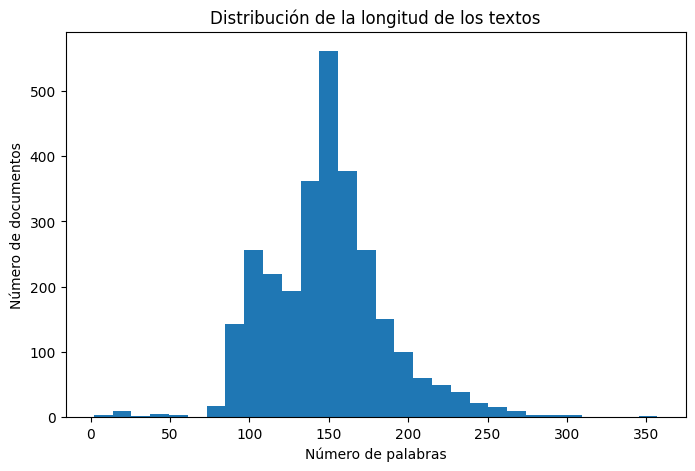

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(corpus_features["n_words"].dropna(), bins=30)
plt.xlabel("Número de palabras")
plt.ylabel("Número de documentos")
plt.title("Distribución de la longitud de los textos")
plt.show()

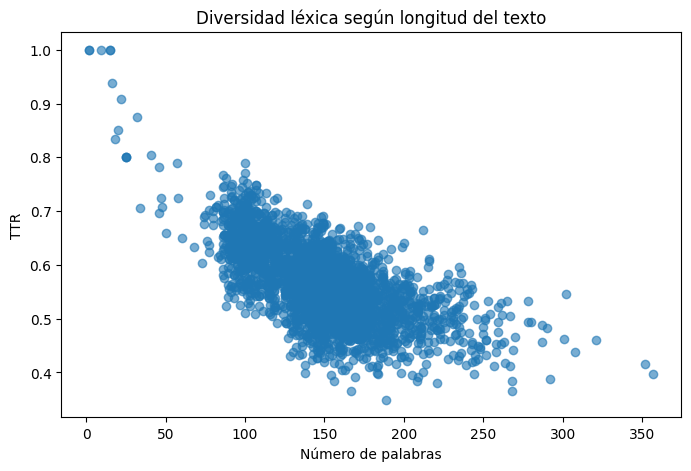

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(
    corpus_features["n_words"],
    corpus_features["ttr"],
    alpha=0.6
)
plt.xlabel("Número de palabras")
plt.ylabel("TTR")
plt.title("Diversidad léxica según longitud del texto")
plt.show()

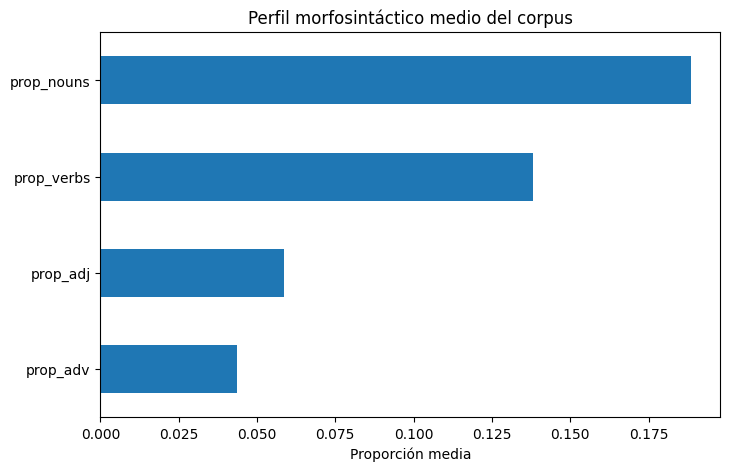

In [33]:
pos_cols = [
    "prop_nouns",
    "prop_verbs",
    "prop_adj",
    "prop_adv"
]

pos_means = corpus_features[pos_cols].mean().sort_values()

plt.figure(figsize=(8, 5))
pos_means.plot(kind="barh")
plt.xlabel("Proporción media")
plt.title("Perfil morfosintáctico medio del corpus")
plt.show()